In [197]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MultipleLocator
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# 读取数据，设置指定列的类型
df1 = pd.read_csv(r"F:\codes\00-WORK\work-1\01-myself\01-predict\02-blind\EXCEL\CSlog_填充.csv",  dtype={'DIPOCE': str, 'BA_Code': str, 'Cata_Code': str})
df1

,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,...,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS,CS_rate,CS_TD,Closed_CC,CS(KPa)
0,110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,59.700000,294.75,5.08,0.0,100000,108.600,0.001667,0,90.8000,212.6
1,110100000,31.0,367.991736,4.464132,1000,18.0,67.567568,2.182432,1.013514,1.013514,...,59.700000,294.75,5.13,0.0,100000,94.100,0.001667,1,90.8000,131.3
2,100010000,31.4,537.000000,5.775221,1000,18.0,1.500000,0.060000,0.025000,0.010000,...,60.000000,35.00,35.00,648.0,10000,225.293,0.002070,0,87.5671,450.0
3,100010000,31.4,698.000000,5.819357,1000,18.0,1.153000,0.038500,0.019000,0.007700,...,53.600000,35.00,35.00,648.0,10000,189.682,0.002047,0,85.2371,520.0
4,100010000,31.4,480.000000,5.949598,1000,18.0,1.670000,0.056000,0.028000,0.011000,...,62.500000,35.00,35.00,648.0,10000,222.207,0.002086,0,88.2515,240.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,110000010,31.0,450.000000,3.000000,1000,18.0,55.555556,0.333333,1.166667,0.222222,...,64.285714,120.00,30.00,48.0,100000,120.000,0.001899,0,96.1000,1670.0
196,110000010,31.0,450.000000,3.000000,1000,18.0,54.644809,0.437158,1.147541,0.218579,...,64.664311,120.00,30.00,48.0,100000,137.000,0.001890,0,95.1000,1330.0
197,110000010,31.0,450.000000,3.000000,1000,18.0,53.475936,0.534759,1.122995,0.213904,...,65.156794,120.00,30.00,48.0,100000,151.000,0.001890,0,94.0000,1090.0
198,110000010,31.0,450.000000,3.000000,1000,18.0,52.631579,0.631579,1.105263,0.210526,...,65.517241,120.00,30.00,48.0,100000,180.000,0.001889,0,93.1000,740.0


In [199]:
df2 = pd.read_csv(r"F:\codes\00-WORK\work-1\01-myself\01-predict\02-blend\EXCEL\CS.csv",  dtype={'DIPOCE': str, 'BA_Code': str, 'Cata_Code': str})
df2.dropna(subset=['CS(KPa)'], how='any', inplace=True) 

df2


,DIPOCE,DI_NCO,PO_HV,PO_f,BA_Code,BA_Mn,PO_Phr,BA_Phr,FS_Phr,Cata_Phr,...,CHS,A_Mix_t,AB_Mix_t,Q,Cata_Code,MCS,CS_rate,CS_TD,Closed_CC,CS(KPa)
0,100100000,31.25,410.000000,5.153492,1000,18.00,105.263158,1.052632,5.263158,0.736842,...,48.700000,127.3040,15.0000,480.0,10000,265.677198,0.002220,1.00,83.102045,347.0
1,100100000,31.25,410.000000,5.133324,1000,18.00,100.000000,1.000000,5.000000,0.700000,...,50.000000,133.8615,15.0000,480.0,10000,267.035787,0.002225,1.00,82.936001,422.0
2,100100000,31.25,410.000000,5.152660,1000,18.00,94.339623,0.943396,4.716981,0.660377,...,51.500000,133.7330,15.0000,480.0,10000,261.661683,0.002222,1.00,83.044071,480.0
3,100100000,31.25,410.000000,5.167921,1000,18.00,90.090090,0.900901,4.504505,0.630631,...,52.600000,137.8720,15.0000,480.0,10000,257.240605,0.002186,1.00,82.846574,482.0
4,100100000,31.25,410.000000,5.172593,1000,18.00,86.206897,0.862069,4.310345,0.603448,...,53.700000,138.4720,15.0000,480.0,10000,263.952358,0.002185,1.00,82.662600,463.0
5,100100000,31.25,410.000000,5.156466,1000,18.00,93.457944,0.467290,4.672897,0.654206,...,51.700000,136.0215,15.0000,480.0,10000,268.331145,0.002230,1.00,82.942594,492.0
6,100100000,31.25,410.000000,5.167921,1000,18.00,90.090090,0.900901,4.504505,0.630631,...,52.600000,137.8720,15.0000,480.0,10000,257.240605,0.002186,1.00,82.846574,484.0
7,100100000,31.25,410.000000,5.207001,1000,18.00,86.956522,1.304348,4.347826,0.608696,...,53.500000,132.9435,15.0000,480.0,10000,260.800088,0.002183,1.00,83.003740,348.0
9,100100000,31.25,410.000000,5.257785,1000,18.00,81.300813,2.032520,4.065041,0.569106,...,55.200000,134.1630,15.0000,480.0,10000,272.475898,0.002179,1.00,83.188284,149.0
10,100100000,31.25,410.000000,5.192504,1000,18.00,90.090090,0.900901,0.900901,0.630631,...,52.600000,137.5425,15.0000,480.0,10000,207.836701,0.001698,1.00,82.859501,444.0


In [200]:
pad_lengths = {
    'DIPOCE': 10,    # 9位
    'BA_Code': 4,   # 4位
    'Cata_Code': 6  # 6位
}

for col, length in pad_lengths.items():
    df1[col] = df1[col].astype(str).str.zfill(length)

pad_lengths = {
    'DIPOCE': 10,    # 9位
    'BA_Code': 4,   # 4位
    'Cata_Code': 6  # 6位
}

for col, length in pad_lengths.items():
    df2[col] = df2[col].astype(str).str.zfill(length)


In [201]:
# 假设标签列叫做 'target'
X_train = df1.drop(columns=['CS(KPa)'])
y_train = np.log10(df1['CS(KPa)'])

X_test = df2.drop(columns=['CS(KPa)'])
y_test = np.log10(df2['CS(KPa)'])

In [202]:
# # 假设标签列叫做 'target'
# X_train = df1.drop(columns=['CS(KPa)'])
# y_train = df1['CS(KPa)']

# X_test = df2.drop(columns=['CS(KPa)'])
# y_test = df2['CS(KPa)']


In [203]:
ratio_count = len(y_test) / len(y_train)
print("y_test / y_train :", ratio_count*100)


y_test / y_train : 11.0


In [204]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.spatial.distance import jensenshannon
from scipy import stats

# 计算核密度估计
kde_train = gaussian_kde(y_train)
kde_test = gaussian_kde(y_test)

# 在相同的点上计算概率密度
x_range = np.linspace(min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max()), 100)
hist_train_smooth = kde_train(x_range)
hist_test_smooth = kde_test(x_range)

# 重新计算 JS 散度
js_divergence_smooth = jensenshannon(hist_train_smooth, hist_test_smooth)
print(f"平滑后 Jensen-Shannon 散度: {js_divergence_smooth}")


平滑后 Jensen-Shannon 散度: 0.3588406476579428


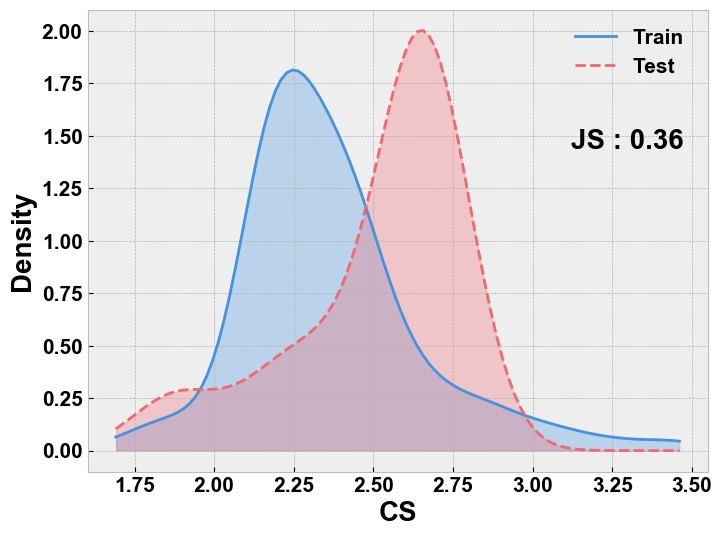

In [205]:
# 绘制平滑后的分布
plt.figure(figsize=(8, 6))
plt.plot(x_range, hist_train_smooth, label='Train ', color="#4493E2", linestyle='-', linewidth=2)
plt.plot(x_range, hist_test_smooth, label='Test ', color="#F3676E", linestyle='--', linewidth=2)
plt.fill_between(x_range, hist_train_smooth, alpha=0.3, color='#4493E2')
plt.fill_between(x_range, hist_test_smooth, alpha=0.3, color="#F3676E")

plt.text(0.78, 0.7, f"JS : {js_divergence_smooth:.2f}", fontsize=20, transform=plt.gca().transAxes)

# 设置标签和其他参数
plt.xlabel("CS", weight='bold', fontsize=20)
plt.ylabel("Density", weight='bold', fontsize=20)
plt.legend(fontsize=15, frameon=False)
plt.grid(True)

# 设置背景透明
plt.gcf().patch.set_alpha(0)  # 设置图表背景透明

# 显示图形
plt.show()

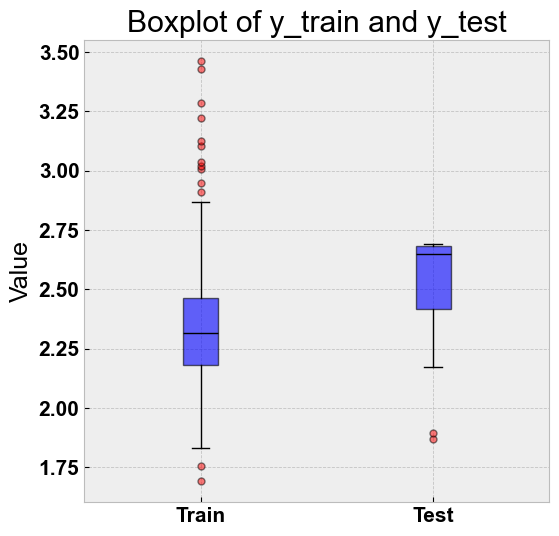

In [206]:
# 颜色定义
train_color = 'blue'
test_color = 'red'

# 创建图形
plt.figure(figsize=(6, 6))

# 绘制箱线图
plt.boxplot([y_train, y_test], vert=True, patch_artist=True, 
            boxprops=dict(facecolor=train_color, alpha=0.6), 
            medianprops=dict(color='black'), 
            whiskerprops=dict(color='black'), 
            capprops=dict(color='black'), 
            flierprops=dict(marker='o', markersize=5, markerfacecolor='red', alpha=0.5))

# 设置 x 轴刻度
plt.xticks([1, 2], ["Train", "Test"])

# 添加标题和坐标轴标签
plt.title("Boxplot of y_train and y_test")
plt.ylabel("Value")

# 添加网格
plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

# 显示图像
plt.show()

In [207]:
params = {'iterations':1100,
            'depth': 4,
            'learning_rate': 0.024,
            'l2_leaf_reg': 2.3,
            'bagging_temperature': 0.27,
            'border_count': 137,
      }

In [208]:
model = CatBoostRegressor(**params, verbose=0, random_state=42)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 计算 R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 计算 MAE
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# 计算 MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# 计算 RMSE
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

# 输出结果
print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
print(f"Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")
print(f"Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")
print(f"Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")



Train R²: 0.9891, Test R²: 0.8087
Train MAE: 0.0233, Test MAE: 0.0843
Train MSE: 0.0009, Test MSE: 0.0122
Train RMSE: 0.0294, Test RMSE: 0.1104


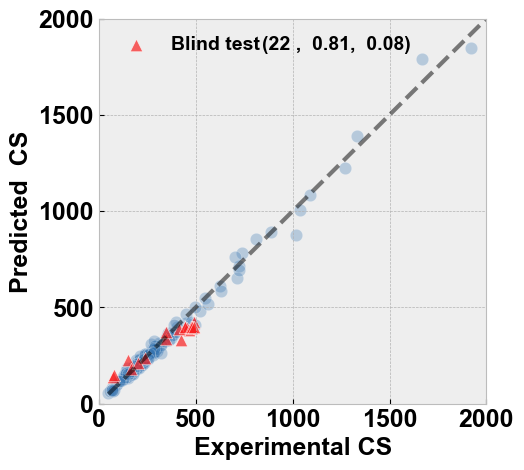

In [209]:
plt.style.use('bmh')
plt.rc('font', weight='bold')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 15
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
# 创建图形和轴
fig, ax = plt.subplots(figsize=(5, 5))
# 绘制训练集和测试集散点图
ax.scatter(10**y_train, 10**y_train_pred, alpha=0.3, c="#3574B1",
            edgecolors='white', s=80, marker='o', label='')
ax.scatter(10**y_test, 10**y_test_pred, alpha=0.7, c="#F81F1F", 
           edgecolors='white', s=80, marker='^', label='Blind test')

# 添加对角线及偏移线
ax.plot([10**y_train.min(), 10**y_train.max()], [10**y_train.min(), 10**y_train.max()], 'k--', lw=3, alpha=0.5)
sigma = np.std(10**y_test)
offset = 1.0 * sigma
# ax.plot([10**y_train.min(), 10**y_train.max()], [10**y_train.min() + offset, 10**y_train.max() + offset], 'k--', lw=3, alpha=0.5)
# ax.plot([10**y_train.min(), 10**y_train.max()], [10**y_train.min() - offset, 10**y_train.max() - offset], 'k--', lw=3, alpha=0.5)
# 统计样本数
train_samples = len(y_train)
test_samples = len(y_test)

# 添加文本信息（R², MAE）
# ax.text(0.27, 0.93, f'({train_samples},  %.2f,  %.2f)' % (model.score(X_train, y_train), train_mae), fontsize=12, transform=ax.transAxes)
ax.text(0.42, 0.92, f'({test_samples} ,  %.2f,  %.2f)' % (model.score(X_test, y_test), test_mae), fontsize=14, transform=ax.transAxes)

# 设置坐标轴范围
ax.set_xlim([0, 2000])
ax.set_ylim([0, 2000])

# 设置坐标轴刻度
ax.xaxis.set_major_locator(MultipleLocator(500))
ax.yaxis.set_major_locator(MultipleLocator(500))

# 设置坐标轴标签
ax.set_xlabel(r'Experimental CS', weight='bold', fontsize=18)
ax.set_ylabel(r'Predicted  CS', weight='bold', fontsize=18)
ax.tick_params(axis='both', labelsize=18)

# 添加图例并去掉边框
ax.legend(loc='upper left', fontsize=14, frameon=False)

plt.savefig("CS.tiff", dpi=600, bbox_inches='tight')
plt.show()